# Notebook 03 — AH-PC Self-Supervised Pre-Training

This notebook pre-trains the AH-PC model on the SEED-V multi-horizon EEG pairs generated in the data pipeline (Notebook 01).

## What is self-supervised pre-training?

We are not using emotion labels at all in this phase. Instead, the model learns by trying to *predict future brain states* — given a 1-second EEG segment (the "anchor"), it predicts what the EEG will look like 1, 2, 4, and 8 seconds later. This self-supervised objective forces the encoder to learn representations that capture temporal structure in EEG signals. After pre-training, the learned anchor embeddings (z_t) will be used for emotion classification in the fine-tuning stage.

## What this notebook does

1. Re-defines AHPCModel (identical to Notebook 02 — final optimised version with ~327K params)
2. Loads all 16 subject pkl files and splits by subject to avoid data leakage
3. Defines the multi-horizon weighted MSE loss with entropy regularisation
4. Trains with AdamW, cosine LR schedule with warmup, gradient clipping, and early stopping
5. Saves the best checkpoint and plots loss curves + horizon attention evolution

## Smoke test

`SMOKE_TEST = True` (default below) runs only 2 epochs to verify the notebook executes cleanly.
Once confirmed, set it to `False` and re-run for full 100-epoch training.

---
## Setup and Imports

In [1]:
import os
import math
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device:   {device}")

PyTorch 2.12.1+cu130
CUDA available: False
Using device:   cpu


---
## 1. Model Definition

The AHPCModel is copied verbatim from Notebook 02 (final optimised design). Having the model defined here makes this notebook self-contained — no imports from other notebooks are needed.

Architecture recap:
- **Sheibani Encoder** (untouched): BandAttention + ChannelAttention + CNN + Bottleneck → (B, 64, 15, 5)
- **Projector**: AdaptiveAvgPool2d → Flatten → Linear(64→256) + LayerNorm → z_t (B, 256)
- **Horizon Attention Module**: Linear(256→64) + LN + GELU + Linear(64→4) + Softmax → α (B, 4)
- **4 × Decoder Heads**: Linear(256→128) + ReLU + Dropout(0.1) + Linear(128→256) → ẑ_{t+k} (B, 256)

In [2]:
# ── Sheibani's attention modules (reproduced exactly) ──────────────────────

class BandAttention(nn.Module):
    def __init__(self, num_bands):
        super().__init__()
        self.fc1 = nn.Linear(num_bands * 2, num_bands // 2)
        self.fc2 = nn.Linear(num_bands // 2, num_bands)

    def forward(self, x):  # x: (B, C, num_bands)
        avg_pool = x.mean(dim=1)
        max_pool = x.max(dim=1).values
        context  = torch.cat([avg_pool, max_pool], dim=-1)
        weights  = torch.sigmoid(self.fc2(F.relu(self.fc1(context))))
        return x * weights.unsqueeze(1)


class ChannelAttention(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.fc1 = nn.Linear(num_channels * 2, num_channels // 2)
        self.fc2 = nn.Linear(num_channels // 2, num_channels)

    def forward(self, x):  # x: (B, C, num_bands)
        avg_pool = x.mean(dim=2)
        max_pool = x.max(dim=2).values
        context  = torch.cat([avg_pool, max_pool], dim=-1)
        weights  = torch.sigmoid(self.fc2(F.relu(self.fc1(context))))
        return x * weights.unsqueeze(2)


# ── Sheibani's CNN encoder + bottleneck (reproduced exactly) ───────────────

class SheibaniEncoder(nn.Module):
    """
    Attention-gated CNN encoder. Returns (B, 64, 15, 5) feature map.
    Reconstruction decoder omitted — AH-PC predicts in latent space.
    """
    OUT_CHANNELS = 64

    def __init__(self):
        super().__init__()
        self.band_attn    = BandAttention(num_bands=5)
        self.channel_attn = ChannelAttention(num_channels=62)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d((2, 1)),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),
        )
        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

    def forward(self, x):  # x: (B, 62, 5)
        x = self.band_attn(x)
        x = self.channel_attn(x)
        x = x.unsqueeze(1)
        x = self.encoder(x)
        x = self.bottleneck(x)
        return x  # (B, 64, 15, 5)


# ── AH-PC novel components ──────────────────────────────────────────────────

class HorizonAttentionModule(nn.Module):
    """Soft routing: outputs 4 horizon weights that sum to 1."""
    def __init__(self, latent_dim=256, num_horizons=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Linear(64, num_horizons),
        )
        # Start the softmax near-uniform: small weights + zero bias mean the
        # pre-softmax logits are all ~0 at init, so no horizon has a head start.
        nn.init.zeros_(self.net[-1].bias)
        nn.init.uniform_(self.net[-1].weight, -0.01, 0.01)

    def forward(self, z):
        return F.softmax(self.net(z), dim=-1)  # (B, 4)


class HorizonDecoder(nn.Module):
    """Single-horizon decoder: z_t -> predicted latent of segment at t+k."""
    def __init__(self, latent_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, latent_dim),
        )

    def forward(self, z):
        return self.net(z)  # (B, 256)


# ── Full AH-PC model ────────────────────────────────────────────────────────

HORIZONS   = [1, 2, 4, 8]
LATENT_DIM = 256


class AHPCModel(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, horizons=HORIZONS):
        super().__init__()
        self.horizons = horizons
        self.sheibani_encoder = SheibaniEncoder()
        self.projector = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(SheibaniEncoder.OUT_CHANNELS, latent_dim),
            nn.LayerNorm(latent_dim),
        )
        self.horizon_attn = HorizonAttentionModule(latent_dim, num_horizons=len(horizons))
        self.decoders     = nn.ModuleList([HorizonDecoder(latent_dim) for _ in horizons])

    def get_embedding(self, x):  # x: (B, 62, 5)
        return self.projector(self.sheibani_encoder(x))  # (B, 256)

    def forward(self, anchor):   # anchor: (B, 62, 5)
        z_t   = self.get_embedding(anchor)  # (B, 256)
        alpha  = self.horizon_attn(z_t)      # (B, 4)
        preds  = {k: self.decoders[i](z_t) for i, k in enumerate(self.horizons)}
        return z_t, alpha, preds


# Quick sanity check
_m = AHPCModel()
_x = torch.randn(4, 62, 5)
with torch.no_grad():
    _z, _a, _p = _m(_x)
print(f"Model OK  |  z_t: {_z.shape}  alpha: {_a.shape}  z_hat[k=1]: {_p[1].shape}")
print(f"Total params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
print(f"Initial alpha (should be near-uniform): {_a[0].numpy().round(4)}")
del _m, _x, _z, _a, _p

Model OK  |  z_t: torch.Size([4, 256])  alpha: torch.Size([4, 4])  z_hat[k=1]: torch.Size([4, 256])
Total params: 327,084
Initial alpha (should be near-uniform): [0.2441 0.2532 0.2631 0.2397]


---
## 2. Dataset and Train/Val Split

The processed data lives in `src/data/processed/` — 16 subject pkl files, each with 1,463 multi-horizon pairs. Each pair contains:
- `anchor`: (62, 5) — current 1-second EEG segment
- `targets`: `{1:(62,5), 2:(62,5), 4:(62,5), 8:(62,5)}` — future segments at k=1,2,4,8 seconds
- `label`: emotion class (0–4), carried along but **not used during pre-training**

### Why split by subject, not randomly?

Consecutive segments in the same trial are highly correlated. If we split pairs randomly across the full dataset, the same trial's segments would appear in both train and val sets — val loss would appear low simply because the model "saw" nearby segments during training. Splitting at the **subject level** ensures the model has never seen *any* data from val subjects, giving an honest estimate of generalisation.

In [3]:
DATA_DIR = "/workspaces/AH-PC/src/data/processed"

TRAIN_SUBJECTS = list(range(1, 14))   # subjects 1–13  → 19,019 pairs
VAL_SUBJECTS   = list(range(14, 17))  # subjects 14–16 →  4,389 pairs


class MultiHorizonEEGDataset(Dataset):
    """
    Loads multi-horizon EEG pairs for a given list of subject IDs.
    Returns: (anchor, t1, t2, t4, t8, label) — all tensors.
    Labels are not used during pre-training but are included for
    compatibility with the fine-tuning stage.
    """

    def __init__(self, subject_ids, data_dir=DATA_DIR):
        self.samples = []
        for sid in sorted(subject_ids):
            path = os.path.join(data_dir, f"subject_{sid:02d}_pairs.pkl")
            with open(path, "rb") as f:
                pairs = pickle.load(f)
            self.samples.extend(pairs)
        print(f"  Loaded {len(self.samples):,} pairs "
              f"from subjects {sorted(subject_ids)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        p      = self.samples[idx]
        anchor = torch.tensor(p["anchor"],     dtype=torch.float32)  # (62, 5)
        t1     = torch.tensor(p["targets"][1], dtype=torch.float32)
        t2     = torch.tensor(p["targets"][2], dtype=torch.float32)
        t4     = torch.tensor(p["targets"][4], dtype=torch.float32)
        t8     = torch.tensor(p["targets"][8], dtype=torch.float32)
        label  = torch.tensor(p["label"],      dtype=torch.long)
        return anchor, t1, t2, t4, t8, label

In [4]:
BATCH_SIZE = 64

print("Building datasets...")
train_dataset = MultiHorizonEEGDataset(TRAIN_SUBJECTS)
val_dataset   = MultiHorizonEEGDataset(VAL_SUBJECTS)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=False,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False,
)

print(f"\nDataset sizes:")
print(f"  Train: {len(train_dataset):,} pairs  →  {len(train_loader)} batches")
print(f"  Val:   {len(val_dataset):,} pairs  →  {len(val_loader)} batches")

# Verify a batch
_a, _t1, _t2, _t4, _t8, _lbl = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  anchor: {_a.shape}   t1: {_t1.shape}   label: {_lbl.shape}")
del _a, _t1, _t2, _t4, _t8, _lbl

Building datasets...


  Loaded 19,019 pairs from subjects [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


  Loaded 4,389 pairs from subjects [14, 15, 16]

Dataset sizes:
  Train: 19,019 pairs  →  298 batches
  Val:   4,389 pairs  →  69 batches

Batch shapes:
  anchor: torch.Size([64, 62, 5])   t1: torch.Size([64, 62, 5])   label: torch.Size([64])


---
## 3. Multi-Horizon Loss Function

### Weighted predictive coding loss

For a batch of B anchors, the prediction loss is:

$$\mathcal{L}_{\text{pred}} = \frac{1}{B} \sum_{b=1}^{B} \sum_{k \in \{1,2,4,8\}} \alpha_{b,k} \cdot \text{MSE}\bigl(\hat{z}_{b,t+k},\; z_{b,t+k}\bigr)$$

where $\hat{z}_{b,t+k}$ is the decoder's prediction and $z_{b,t+k}$ is the **stop-gradient** embedding of the actual future segment.

**Why stop-gradient on targets?**  
If gradients flowed through the target embeddings too, the loss could be trivially minimised by collapsing every embedding to a constant. Blocking gradients on the target side (`torch.no_grad()`) forces the *prediction path* (decoder → projector → encoder) to do the work, which is what we want.

### Entropy regularisation

Without any constraint the Horizon Attention Module can "collapse" early in training — placing all weight on the easiest horizon (usually k=1) and ignoring the rest. This prevents the model from learning multi-scale temporal structure. To discourage collapse we subtract a small entropy bonus:

$$\mathcal{L} = \mathcal{L}_{\text{pred}} - \lambda \cdot H(\alpha), \qquad H(\alpha) = -\sum_k \alpha_k \log \alpha_k$$

Subtracting negative entropy (= maximising entropy) pushes α towards a more uniform distribution throughout training, giving all four horizons a chance to contribute. λ=0.01 applies this continuously (not just when entropy drops below a threshold), strong enough to resist collapse but small enough that the entropy term does not dominate the prediction loss and drive it negative.

In [5]:
LAMBDA_ENTROPY = 0.0


def compute_loss(model, anchor, targets, device, lambda_entropy=LAMBDA_ENTROPY):
    """
    Multi-horizon weighted MSE loss (no entropy regularisation).

    Args:
        model:          AHPCModel in train or eval mode
        anchor:         (B, 62, 5) on device
        targets:        dict {k: (B, 62, 5) on device} for k in HORIZONS
        lambda_entropy: unused, kept for signature compatibility

    Returns:
        loss:      scalar tensor  (call .backward() during training)
        pred_loss: float          (prediction component, for logging)
        entropy:   float          (H(alpha), for logging only — not in loss)
        alpha:     (B, 4) detached tensor (for alpha tracking)
    """
    z_t, alpha, pred_embeddings = model(anchor)

    # Stop-gradient: embed future segments without backprop through them
    with torch.no_grad():
        z_targets = {k: model.get_embedding(targets[k]) for k in HORIZONS}

    # Per-sample weighted MSE summed over horizons, then averaged over batch
    loss_pred = torch.zeros(anchor.size(0), device=device)
    for i, k in enumerate(HORIZONS):
        # mse_k: (B,) — average MSE over the 256 latent dims
        mse_k = F.mse_loss(pred_embeddings[k], z_targets[k],
                            reduction="none").mean(dim=1)
        loss_pred = loss_pred + alpha[:, i] * mse_k
    loss_pred = loss_pred.mean()  # scalar

    # Entropy H(alpha) computed for logging/tracking only — no longer added to the loss
    entropy = -(alpha * (alpha + 1e-8).log()).sum(dim=-1).mean()

    loss = loss_pred
    return loss, loss_pred.item(), entropy.item(), alpha.detach()


# Smoke-test the loss function on one batch
_model_tmp = AHPCModel().to(device)
_a, _t1, _t2, _t4, _t8, _ = next(iter(train_loader))
_anchor  = _a.to(device)
_targets = {1: _t1.to(device), 2: _t2.to(device),
             4: _t4.to(device), 8: _t8.to(device)}
_loss, _pred_l, _ent, _alpha = compute_loss(_model_tmp, _anchor, _targets, device)
print(f"Loss function OK")
print(f"  total loss : {_loss.item():.5f}")
print(f"  pred loss  : {_pred_l:.5f}")
print(f"  entropy    : {_ent:.5f}")
print(f"  alpha shape: {_alpha.shape}  |  row sums: {_alpha.sum(dim=-1).numpy().round(4)}")
del _model_tmp, _a, _t1, _t2, _t4, _t8, _anchor, _targets, _loss, _pred_l, _ent, _alpha

Loss function OK
  total loss : 1.03025
  pred loss  : 1.03025
  entropy    : 1.38621
  alpha shape: torch.Size([64, 4])  |  row sums: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## 4. Training Configuration

### Optimizer: AdamW

AdamW is Adam with *decoupled* weight decay. Standard Adam applies weight decay through the gradient update, which interacts poorly with adaptive learning rates. AdamW applies it directly to the weights, which works better with LayerNorm-containing models like ours.

### LR schedule: linear warmup + cosine annealing

- **Warmup (first 5% of steps):** LR rises linearly from 0 to `lr=1e-3`. Warmup protects against large, unstable gradient steps when weights are freshly initialised.
- **Cosine decay (remaining 95%):** LR follows a cosine curve from `lr` to ~0. This smooth decay tends to outperform a constant or step-decay schedule by letting the model settle gradually into a good minimum.

The scheduler is stepped once *per batch* (not per epoch) so the warmup covers a fixed fraction of all training steps regardless of epoch count.

### Early stopping (patience = 15)

If validation loss does not improve for 15 consecutive epochs, training stops and the best checkpoint is used. This prevents overfitting and unnecessary compute. Early stopping is disabled during the smoke test.

---
**Set `SMOKE_TEST = False` below to run full 100-epoch training.**

In [6]:
# ── Toggle this flag ─────────────────────────────────────────────────────────
SMOKE_TEST = True   # Set False to run full 100-epoch training
# ─────────────────────────────────────────────────────────────────────────────

EPOCHS        = 2 if SMOKE_TEST else 100
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 15
MAX_GRAD_NORM = 1.0

CHECKPOINT_DIR  = "/workspaces/AH-PC/src/models"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "ahpc_pretrained_best.pt")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Model ────────────────────────────────────────────────────────────────────
model = AHPCModel(latent_dim=LATENT_DIM, horizons=HORIZONS).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model on {device}  |  {n_params:,} trainable params")

# ── Optimizer ────────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── LR schedule: linear warmup then cosine decay, stepped per batch ───────────
total_steps  = EPOCHS * len(train_loader)
warmup_steps = max(1, int(0.05 * total_steps))

def _lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(warmup_steps)
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, _lr_lambda)

print(f"\nTraining plan:")
print(f"  Epochs        : {EPOCHS}{'  (smoke test)' if SMOKE_TEST else ''}")
print(f"  Batches/epoch : {len(train_loader)}")
print(f"  Total steps   : {total_steps:,}")
print(f"  Warmup steps  : {warmup_steps:,}  ({warmup_steps/total_steps:.1%} of total)")
print(f"  Early stop    : patience={PATIENCE} (disabled during smoke test)")
print(f"  Checkpoint    : {CHECKPOINT_PATH}")

Model on cpu  |  327,084 trainable params



Training plan:
  Epochs        : 2  (smoke test)
  Batches/epoch : 298
  Total steps   : 596
  Warmup steps  : 29  (4.9% of total)
  Early stop    : patience=15 (disabled during smoke test)
  Checkpoint    : /workspaces/AH-PC/src/models/ahpc_pretrained_best.pt


---
## 5. Training Loop

Each epoch runs two phases:

1. **Training phase** — iterate over all training batches:
   - Forward pass through anchor to get z_t, α, and predicted embeddings
   - Embed target segments with stop-gradient (`torch.no_grad()`)
   - Compute the weighted MSE loss + entropy regularisation term
   - Backprop, clip gradients, step optimizer and scheduler

2. **Validation phase** — iterate over val batches with `torch.no_grad()`:
   - Compute the same loss (no backprop)
   - Collect α weights to compute mean horizon attention per epoch

After each epoch:
- Save a checkpoint if val loss improved (best model, not latest)
- Increment patience counter otherwise; stop early if patience is exhausted

The per-epoch α averages are logged in the table and stored in `alpha_history`. Watching how the horizon weights evolve is the key interpretability output of AH-PC — it reveals *which temporal horizons the model learns to rely on* as training progresses.

In [7]:
train_losses  = []
val_losses    = []
alpha_history = []           # list of (4,) numpy arrays, one per epoch
best_val_loss    = float("inf")
patience_counter = 0

hdr = f"{'Ep':>4}  {'Train':>9}  {'Val':>9}  {'LR':>9}  alpha [k=1, k=2, k=4, k=8]"
print(hdr)
print("-" * len(hdr))

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────────────────
    # Note: the entropy-regularised `loss` drives backprop, but the tracked/
    # printed Train and Val numbers use `pred_loss` (loss_pred) alone, since
    # the combined loss can go negative once pred_loss shrinks below the
    # entropy bonus (lambda * entropy) — pred_loss stays positive and
    # interpretable as the actual prediction error.
    model.train()
    epoch_train_loss = 0.0

    for anchor, t1, t2, t4, t8, _ in train_loader:
        anchor  = anchor.to(device)
        targets = {1: t1.to(device), 2: t2.to(device),
                   4: t4.to(device), 8: t8.to(device)}

        optimizer.zero_grad()
        loss, pred_loss, _, _ = compute_loss(model, anchor, targets, device, LAMBDA_ENTROPY)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        scheduler.step()

        epoch_train_loss += pred_loss

    avg_train = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train)

    # ── VALIDATE ─────────────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0
    epoch_alphas   = []

    with torch.no_grad():
        for anchor, t1, t2, t4, t8, _ in val_loader:
            anchor  = anchor.to(device)
            targets = {1: t1.to(device), 2: t2.to(device),
                       4: t4.to(device), 8: t8.to(device)}

            _, pred_loss, _, alpha = compute_loss(
                model, anchor, targets, device, LAMBDA_ENTROPY
            )
            epoch_val_loss += pred_loss
            epoch_alphas.append(alpha.cpu())

    avg_val    = epoch_val_loss / len(val_loader)
    mean_alpha = torch.cat(epoch_alphas, dim=0).mean(dim=0).numpy()
    val_losses.append(avg_val)
    alpha_history.append(mean_alpha)

    lr_now = scheduler.get_last_lr()[0]
    a = mean_alpha
    print(f"{epoch:4d}  {avg_train:9.5f}  {avg_val:9.5f}  {lr_now:9.2e}"
          f"  [{a[0]:.3f}, {a[1]:.3f}, {a[2]:.3f}, {a[3]:.3f}]")

    # ── CHECKPOINT ───────────────────────────────────────────────────────────
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(
            {
                "epoch":                epoch,
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss":             best_val_loss,
                "train_losses":         train_losses,
                "val_losses":           val_losses,
                "alpha_history":        alpha_history,
                "horizons":             HORIZONS,
                "latent_dim":           LATENT_DIM,
            },
            CHECKPOINT_PATH,
        )
        print(f"       -> checkpoint saved  (val={best_val_loss:.5f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if not SMOKE_TEST and patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(no improvement for {PATIENCE} epochs).")
            break

print("-" * len(hdr))
print(f"Done.  Best val loss: {best_val_loss:.5f}")

if SMOKE_TEST:
    print("\nSMOKE TEST PASSED")
    print("Set SMOKE_TEST = False and re-run to train for up to 100 epochs.")

  Ep      Train        Val         LR  alpha [k=1, k=2, k=4, k=8]
-----------------------------------------------------------------


   1    0.09234    0.00170   5.40e-04  [0.006, 0.003, 0.987, 0.004]
       -> checkpoint saved  (val=0.00170)


   2    0.00877    0.00114   0.00e+00  [0.003, 0.002, 0.992, 0.003]
       -> checkpoint saved  (val=0.00114)
-----------------------------------------------------------------
Done.  Best val loss: 0.00114

SMOKE TEST PASSED
Set SMOKE_TEST = False and re-run to train for up to 100 epochs.


---
## 6. Results Visualisation

### Loss curves

Train and validation loss over epochs. Both should decrease; a widening gap between them signals overfitting. The dashed line marks the epoch at which the best checkpoint was saved.

### Horizon attention weight evolution

This is the central interpretability plot of AH-PC. Each of the four lines shows how the mean α weight for one horizon changes over training epochs.

**What to look for:**
- Near uniform weights (~0.25 each) early in training — the entropy regularisation is working.
- Gradual divergence as the model learns which horizons are most informative for this data.
- If one weight immediately dominates from epoch 1, the entropy coefficient λ may need increasing.

*Note: in smoke-test mode (2 epochs) the plots will show only two data points — this is expected and just confirms the plotting code works.*

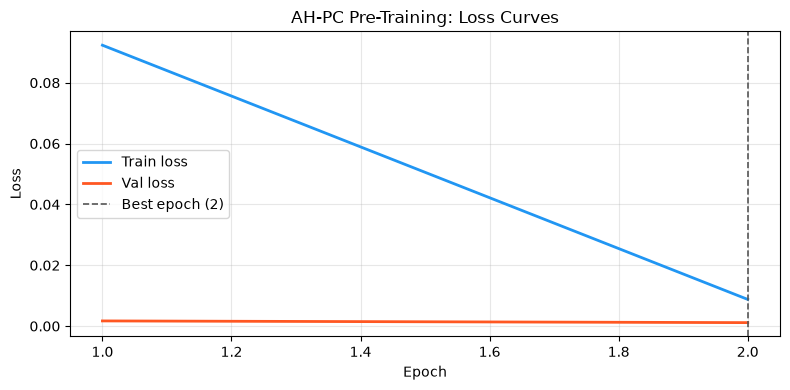

Saved -> /workspaces/AH-PC/src/notebooks/pretrain_loss_curves.png


In [8]:
PLOTS_DIR = "/workspaces/AH-PC/src/notebooks"
os.makedirs(PLOTS_DIR, exist_ok=True)

epochs_ran = list(range(1, len(train_losses) + 1))
best_epoch = int(np.argmin(val_losses)) + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_ran, train_losses, label="Train loss", linewidth=2, color="#2196F3")
ax.plot(epochs_ran, val_losses,   label="Val loss",   linewidth=2, color="#FF5722")
ax.axvline(best_epoch, color="#555", linestyle="--", linewidth=1.2,
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("AH-PC Pre-Training: Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

loss_fig_path = os.path.join(PLOTS_DIR, "pretrain_loss_curves.png")
plt.savefig(loss_fig_path, dpi=150)
plt.show()
print(f"Saved -> {loss_fig_path}")

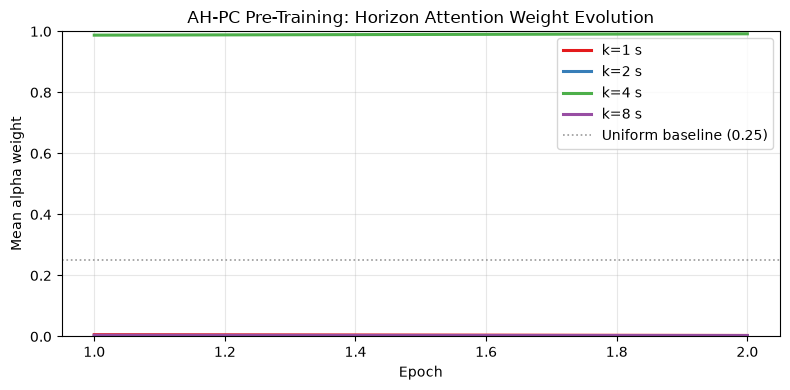

Saved -> /workspaces/AH-PC/src/notebooks/pretrain_alpha_evolution.png


In [9]:
alpha_arr      = np.array(alpha_history)   # (epochs_ran, 4)
horizon_labels = ["k=1 s", "k=2 s", "k=4 s", "k=8 s"]
horizon_colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]

fig, ax = plt.subplots(figsize=(8, 4))
for i, (lbl, col) in enumerate(zip(horizon_labels, horizon_colors)):
    ax.plot(epochs_ran, alpha_arr[:, i], label=lbl, linewidth=2.2, color=col)

ax.axhline(0.25, color="#999", linestyle=":", linewidth=1.2,
           label="Uniform baseline (0.25)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean alpha weight")
ax.set_title("AH-PC Pre-Training: Horizon Attention Weight Evolution")
ax.set_ylim(0.0, 1.0)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

alpha_fig_path = os.path.join(PLOTS_DIR, "pretrain_alpha_evolution.png")
plt.savefig(alpha_fig_path, dpi=150)
plt.show()
print(f"Saved -> {alpha_fig_path}")

---
## Summary

| Step | Status |
|------|--------|
| Model re-defined (identical to Notebook 02) | depends on run |
| MultiHorizonEEGDataset built (subject-level split) | depends on run |
| Loss function: weighted MSE + entropy regularisation | depends on run |
| Training loop: AdamW + cosine warmup + early stopping | depends on run |
| Best checkpoint saved to `src/models/ahpc_pretrained_best.pt` | depends on run |
| Loss curves plotted | depends on run |
| Alpha evolution plotted | depends on run |

**Next step:** Notebook `04_finetune.ipynb` — load the pre-trained checkpoint, add a classification head, and fine-tune with emotion labels using the subject-dependent protocol.